# Assess scVI output

In [1]:
here::i_am("rna/trajectories/infer_trajectory.R")

suppressPackageStartupMessages(library(uwot))
suppressPackageStartupMessages(library(destiny))


# Load default settings
source(here::here("settings.R"))
source(here::here("utils.R"))

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/code

Warning message:
“package ‘destiny’ was built under R version 4.1.3”


In [2]:
args <- list()
args$outdir <- file.path(io$basedir,"results/epiblast_blood")
args$trajectory_name <- "epiblast_blood"

sample_metadata = fread(file.path(args$outdir,sprintf("%s_sample_metadata.txt.gz",args$trajectory_name)))

# Model 1

In [6]:
latent = fread(sprintf('%s/results/epiblast_blood/scVI_latent.csv', io$basedir))[-1,-1] %>%
    setnames(c(paste0('VI_', 1:25)))

In [34]:
set.seed(1234)
args$min_dist = 0.3
args$n_neighbors = 35
get_umap = function(n_neighbors = 25, min_dist=0.3, plot=FALSE){
    umap.mtx = umap(latent, 
                    n_neighbors = n_neighbors,
                    min_dist = min_dist)

    # Fetch UMAP coordinates
    umap.dt <- umap.mtx %>% as.data.table %>% 
      .[,cell:=sample_metadata$cell] %>%
      setnames(c("UMAP1","UMAP2","cell")) %>%
      merge(.,sample_metadata[,c('cell', 'celltype', 'stage')], by='cell')

    # Plot umap
    p1 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=celltype)) + 
        geom_point() + 
        scale_colour_manual(values=opts$celltype.colors) + 
        ggtitle('celltype') + 
        theme_void() + 
        theme(legend.position="none")
    p2 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=stage)) + 
        geom_point() + 
        scale_colour_manual(values=opts$stage.colors) + 
        ggtitle('celltype') + 
        theme_void() + 
        theme(legend.position="none")
    options(repr.plot.width=20, repr.plot.height=6)
    
    if(plot==TRUE){ggarrange(p1, p2)}
    else{return(umap.dt)}
    
}

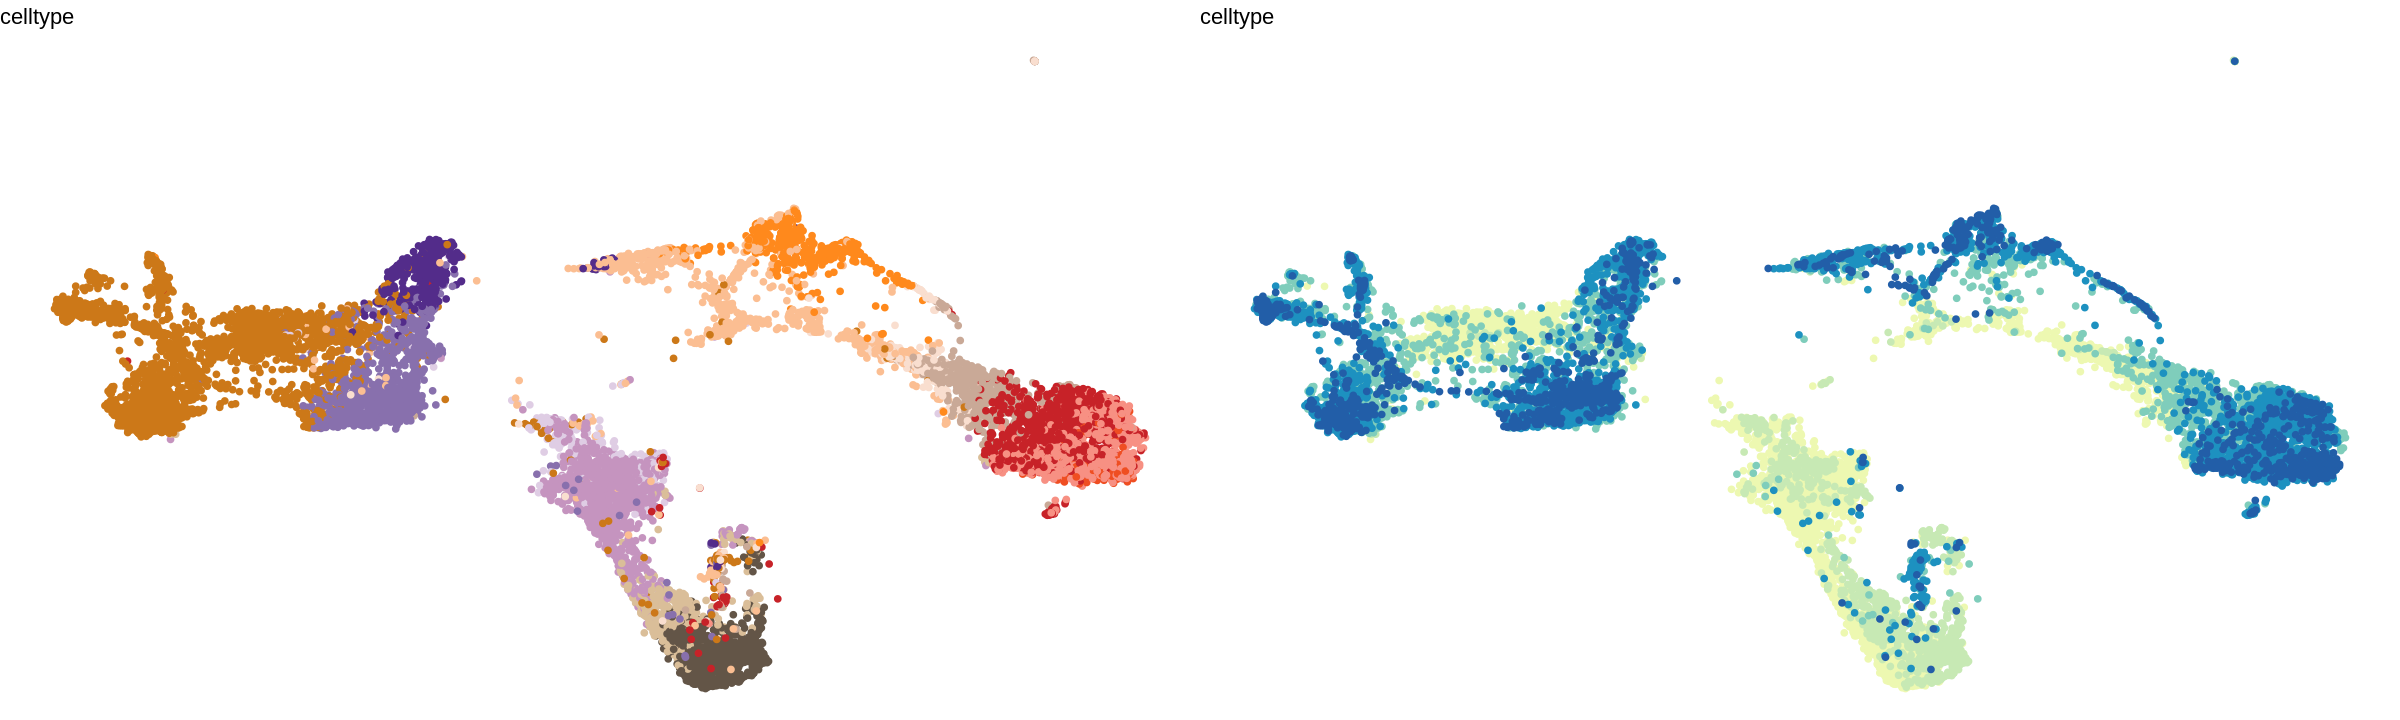

In [36]:
get_umap(20, 0.01, plot=TRUE)

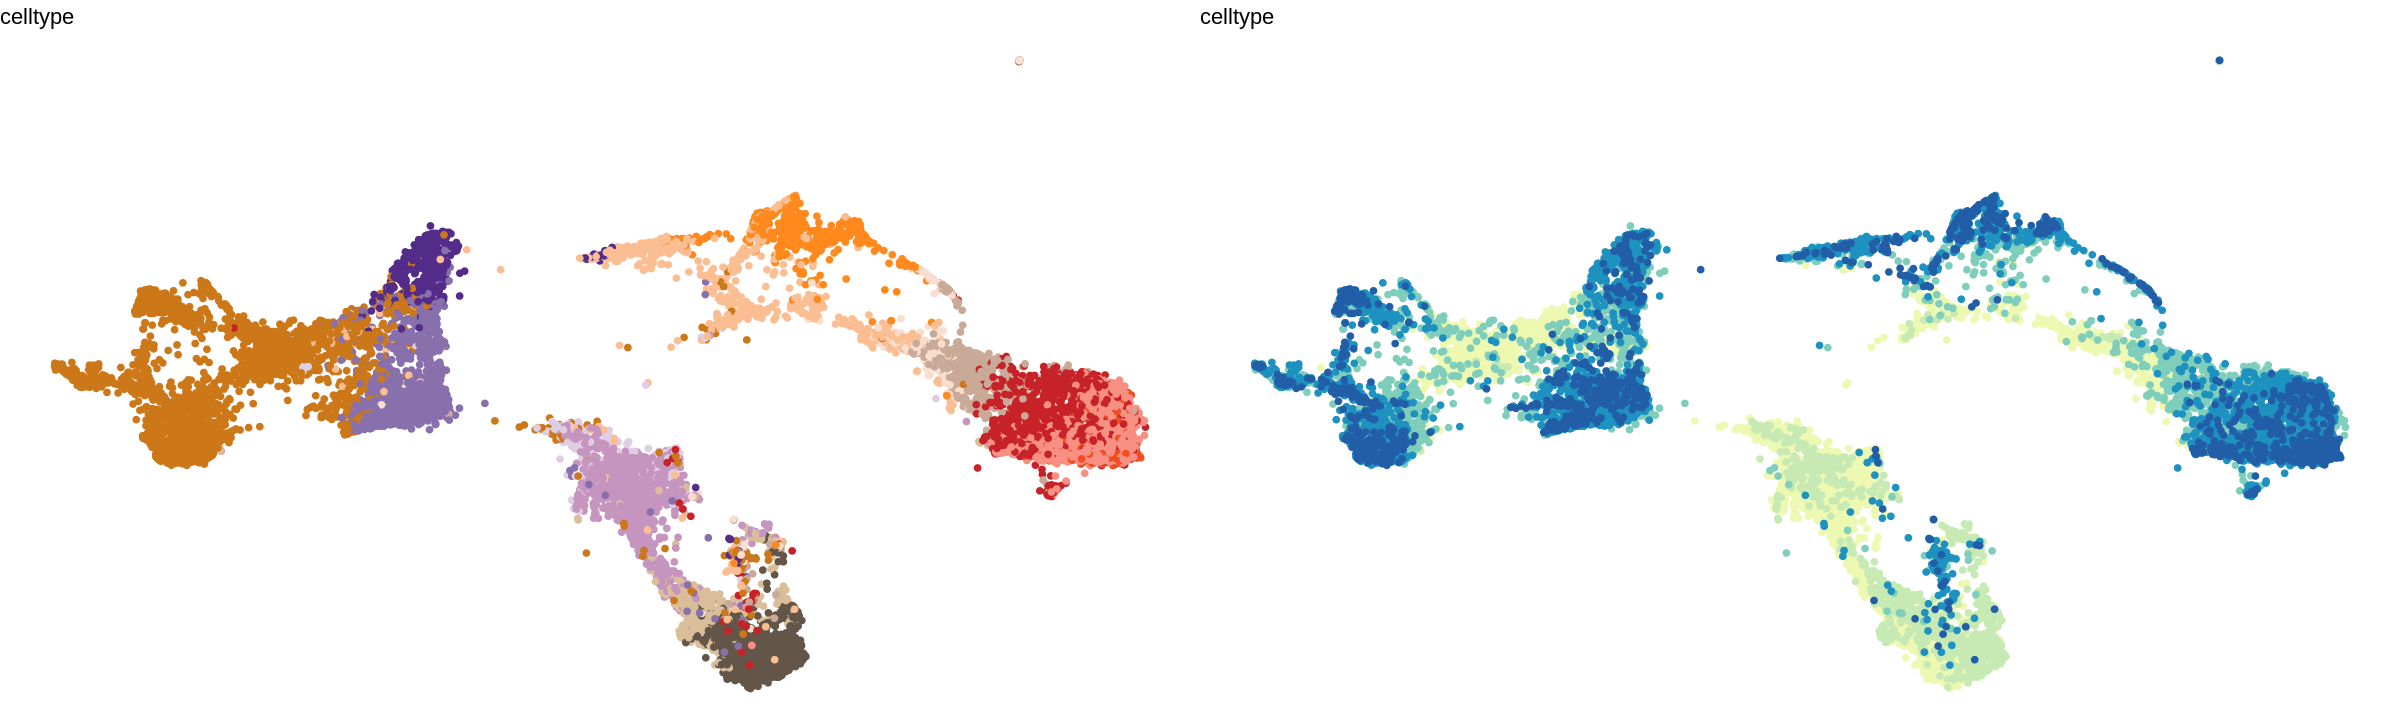

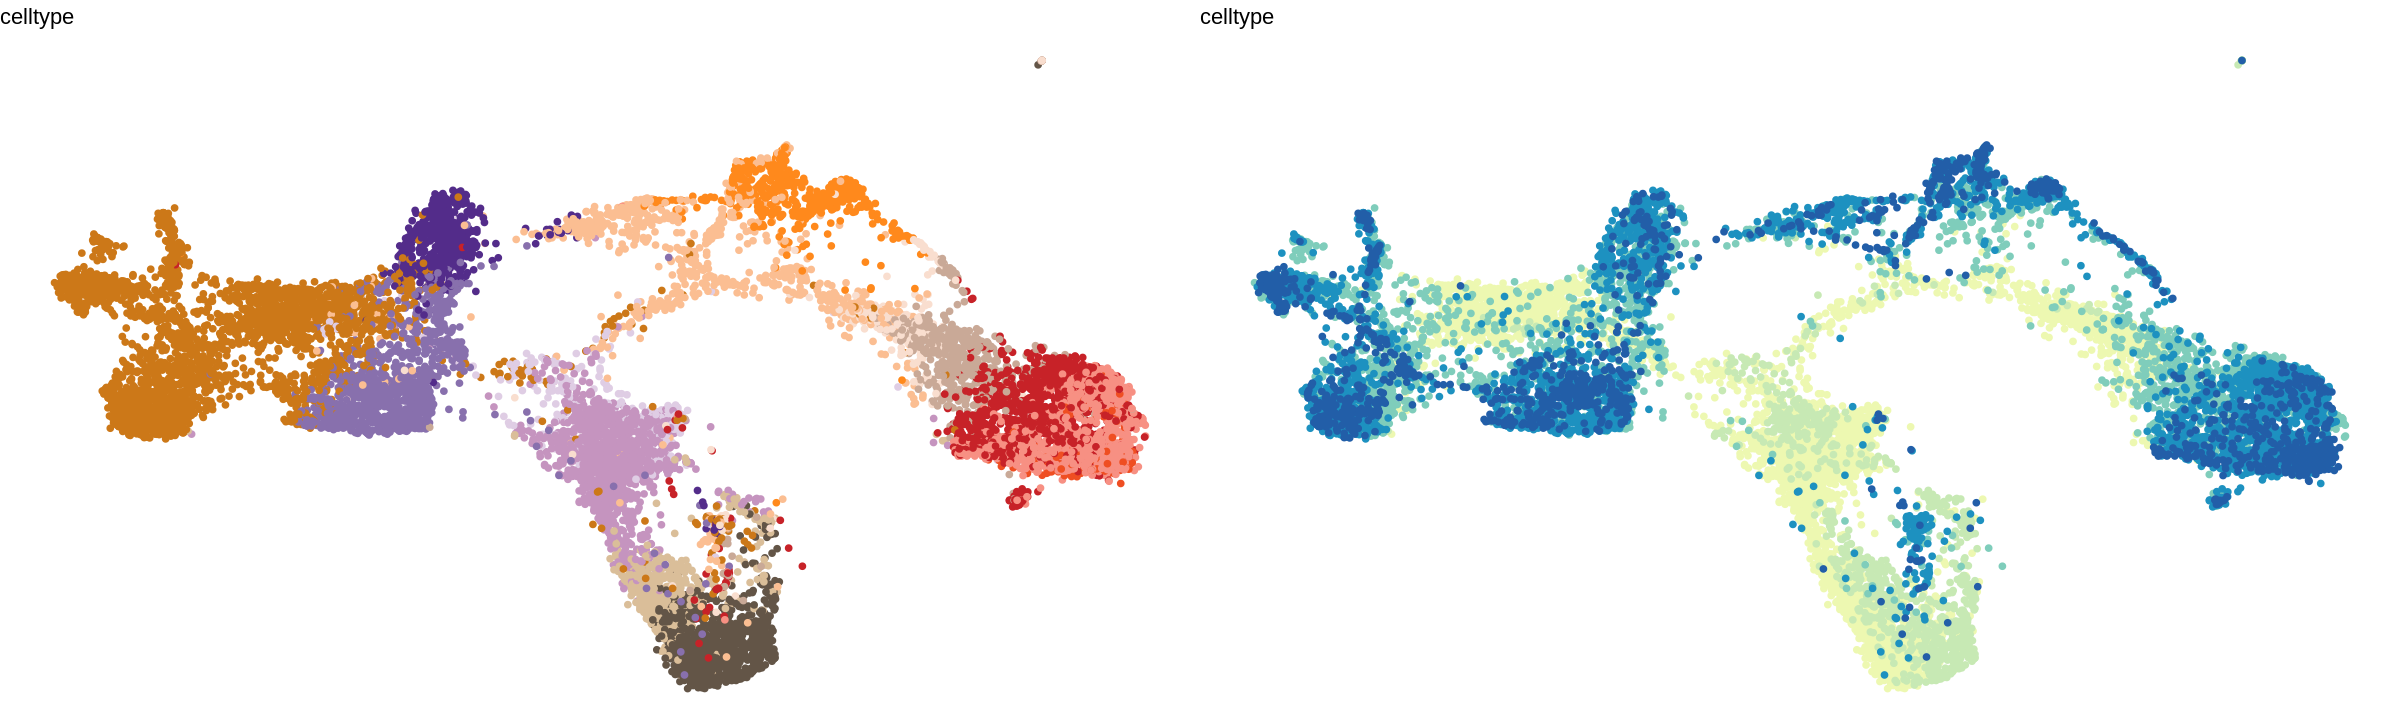

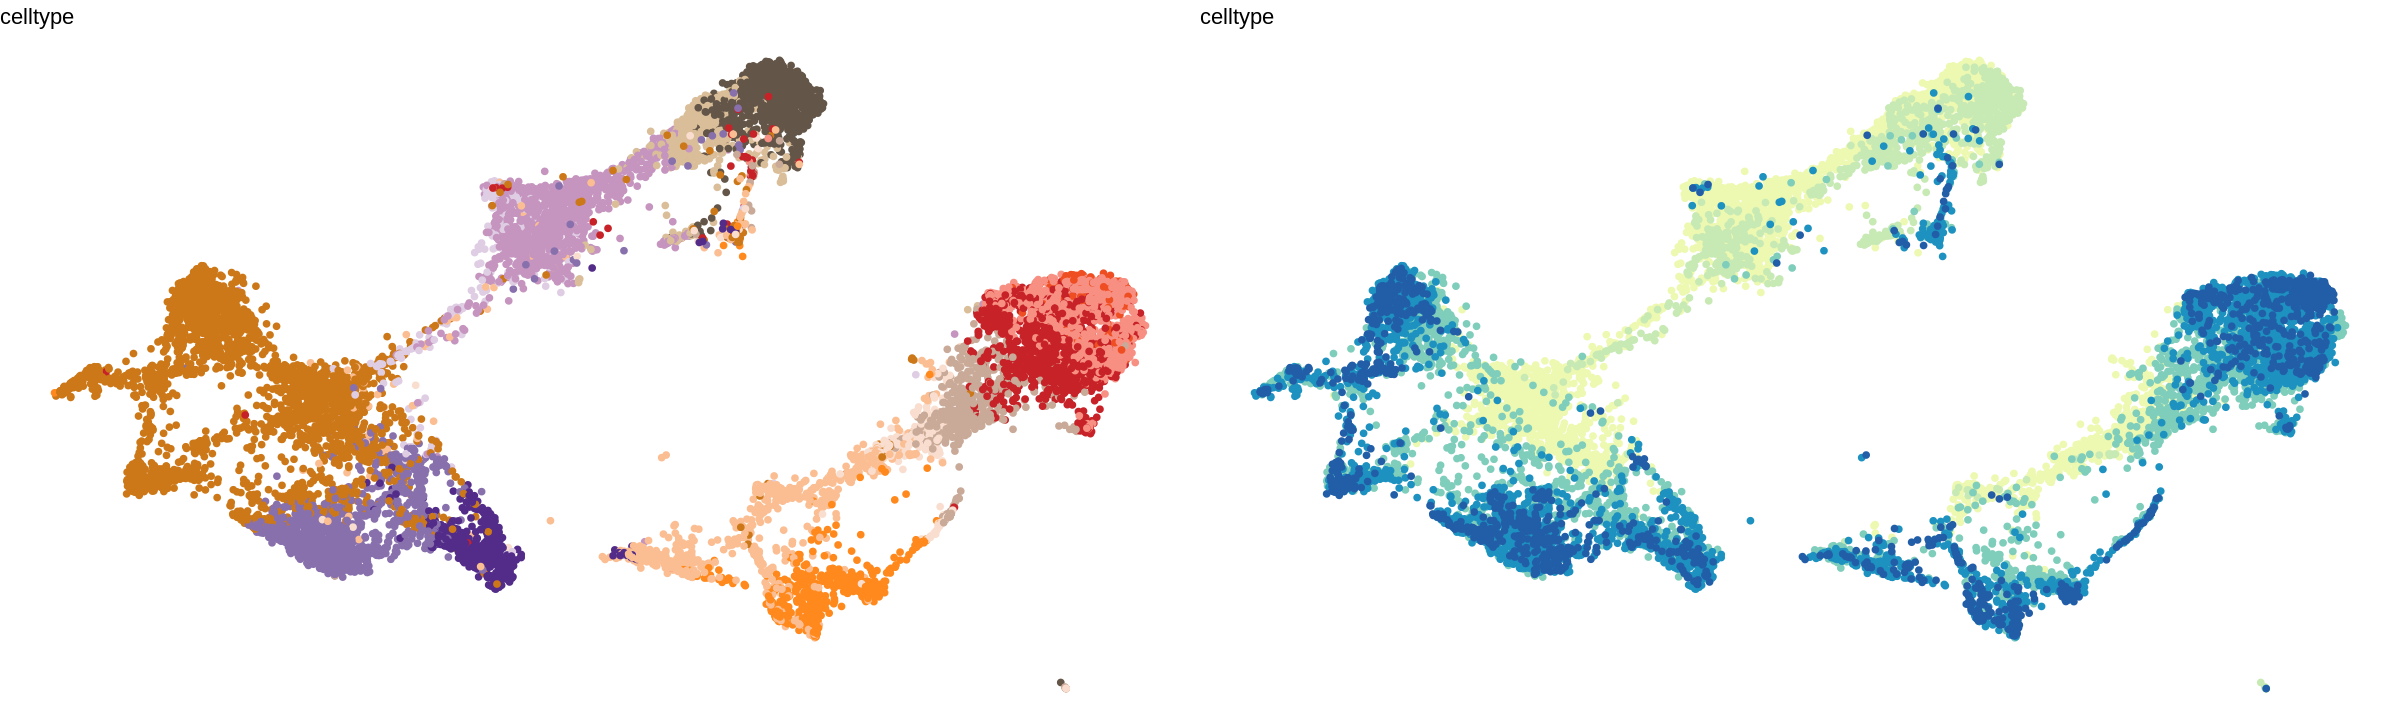

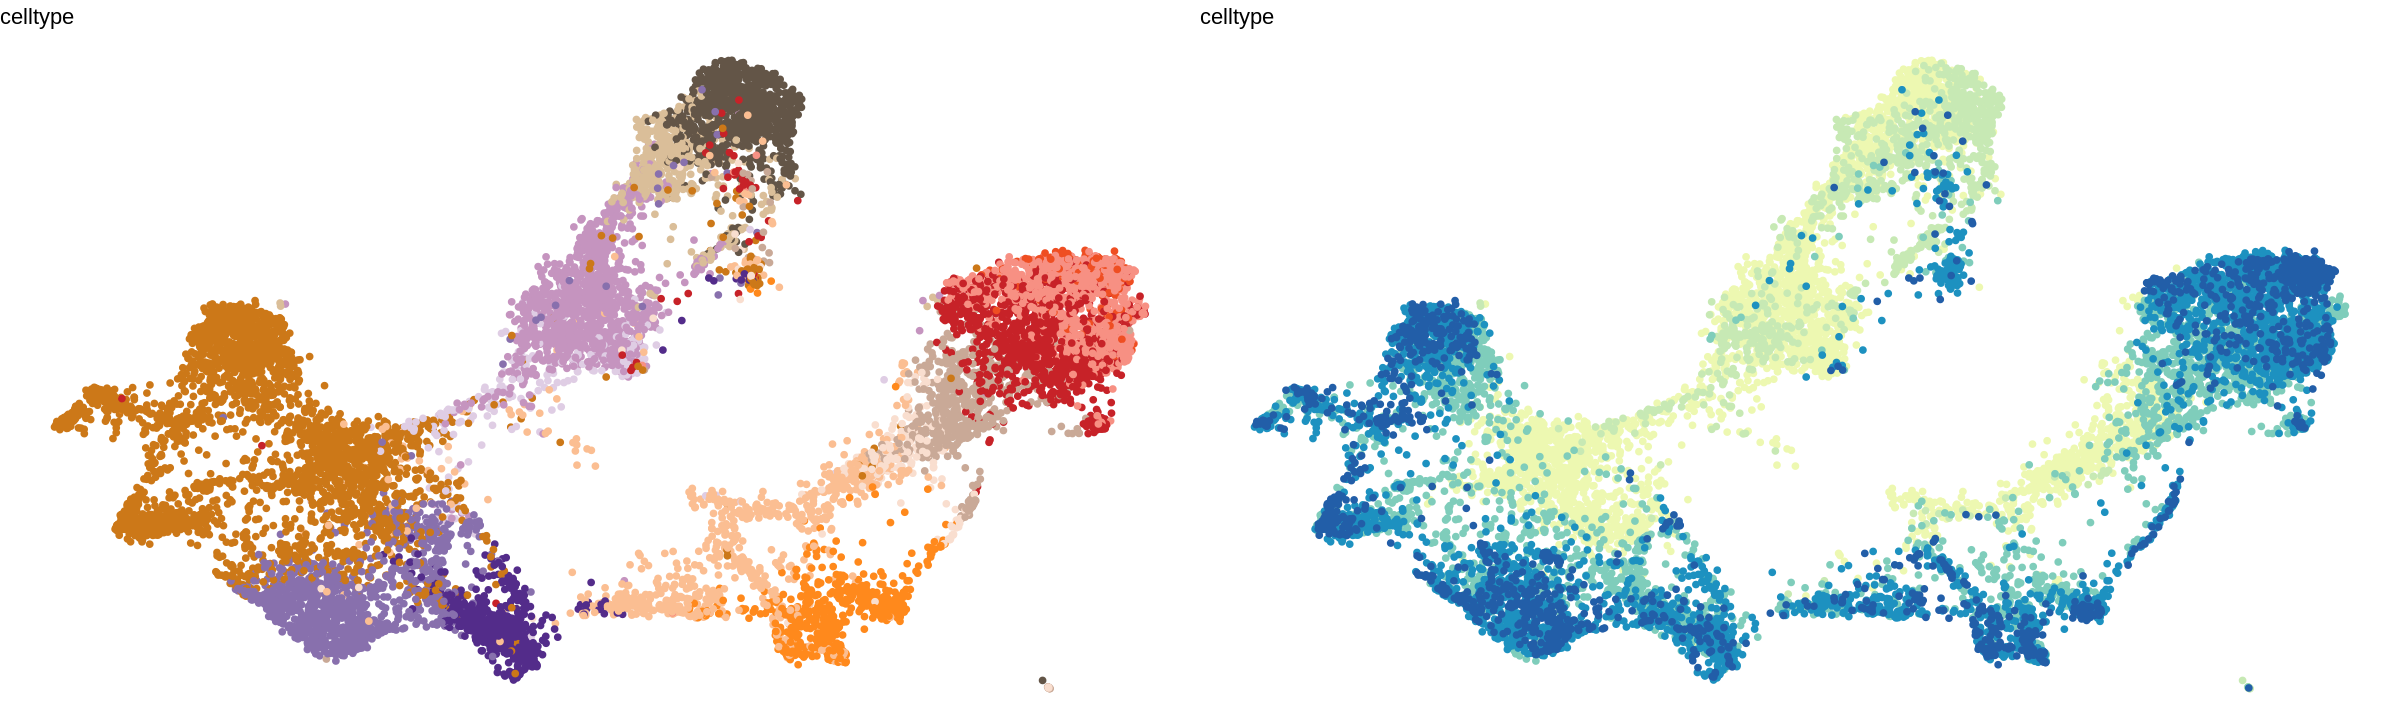

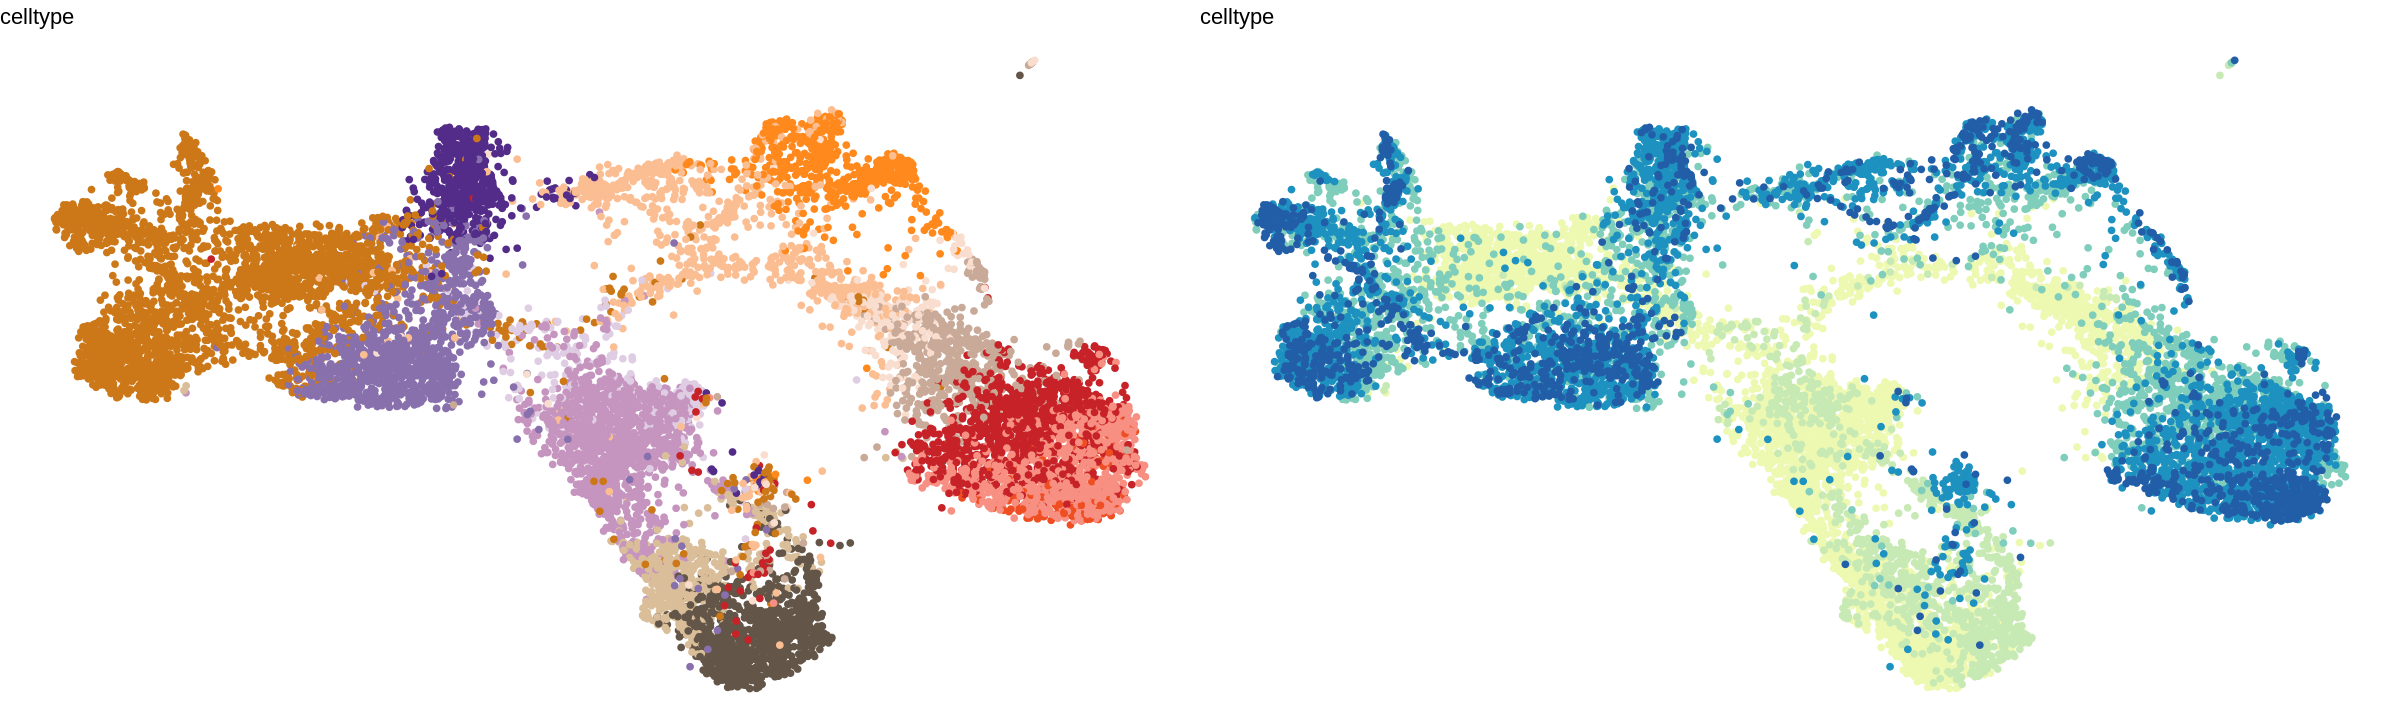

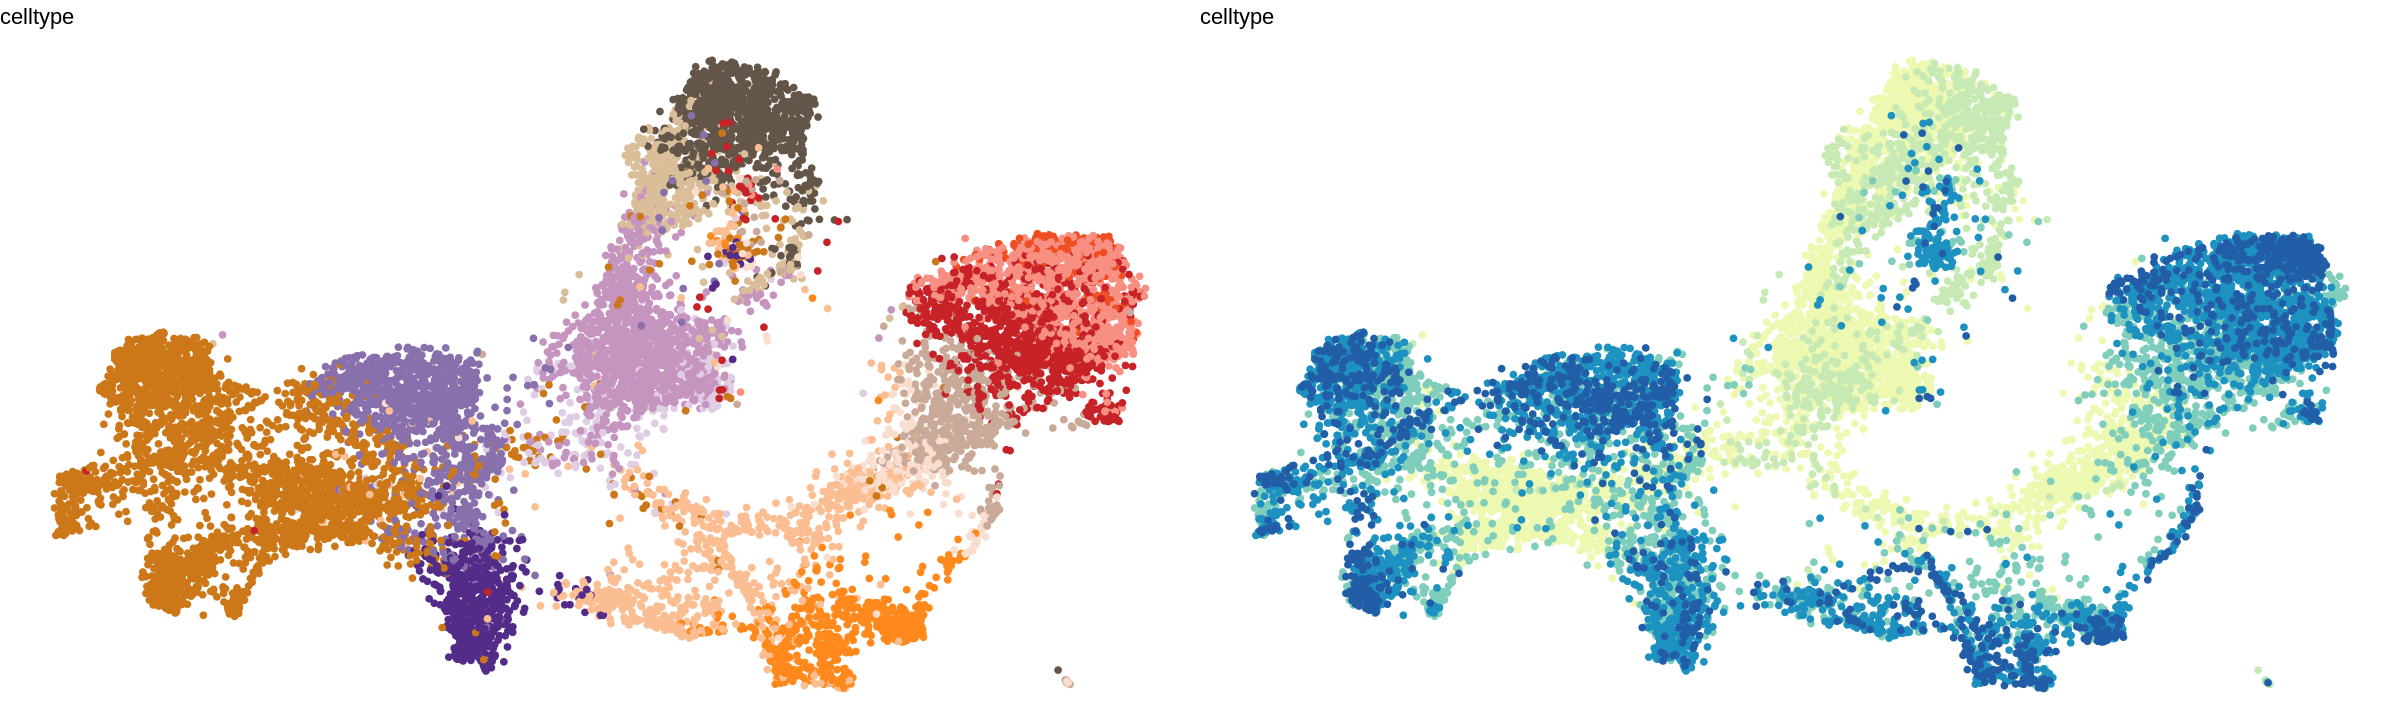

In [37]:
get_umap(20, 0.01, plot=TRUE)
get_umap(20, 0.1, plot=TRUE)
get_umap(25, 0.01, plot=TRUE)
get_umap(25, 0.1, plot=TRUE)
get_umap(20, 0.2, plot=TRUE)
get_umap(25, 0.2, plot=TRUE)

In [18]:
dm <- DiffusionMap(latent, n_pcs=10, k = 25)
# Add to the SingleCellExperiment object
dm.mtx <- dm@eigenvectors[,c(1,2)]

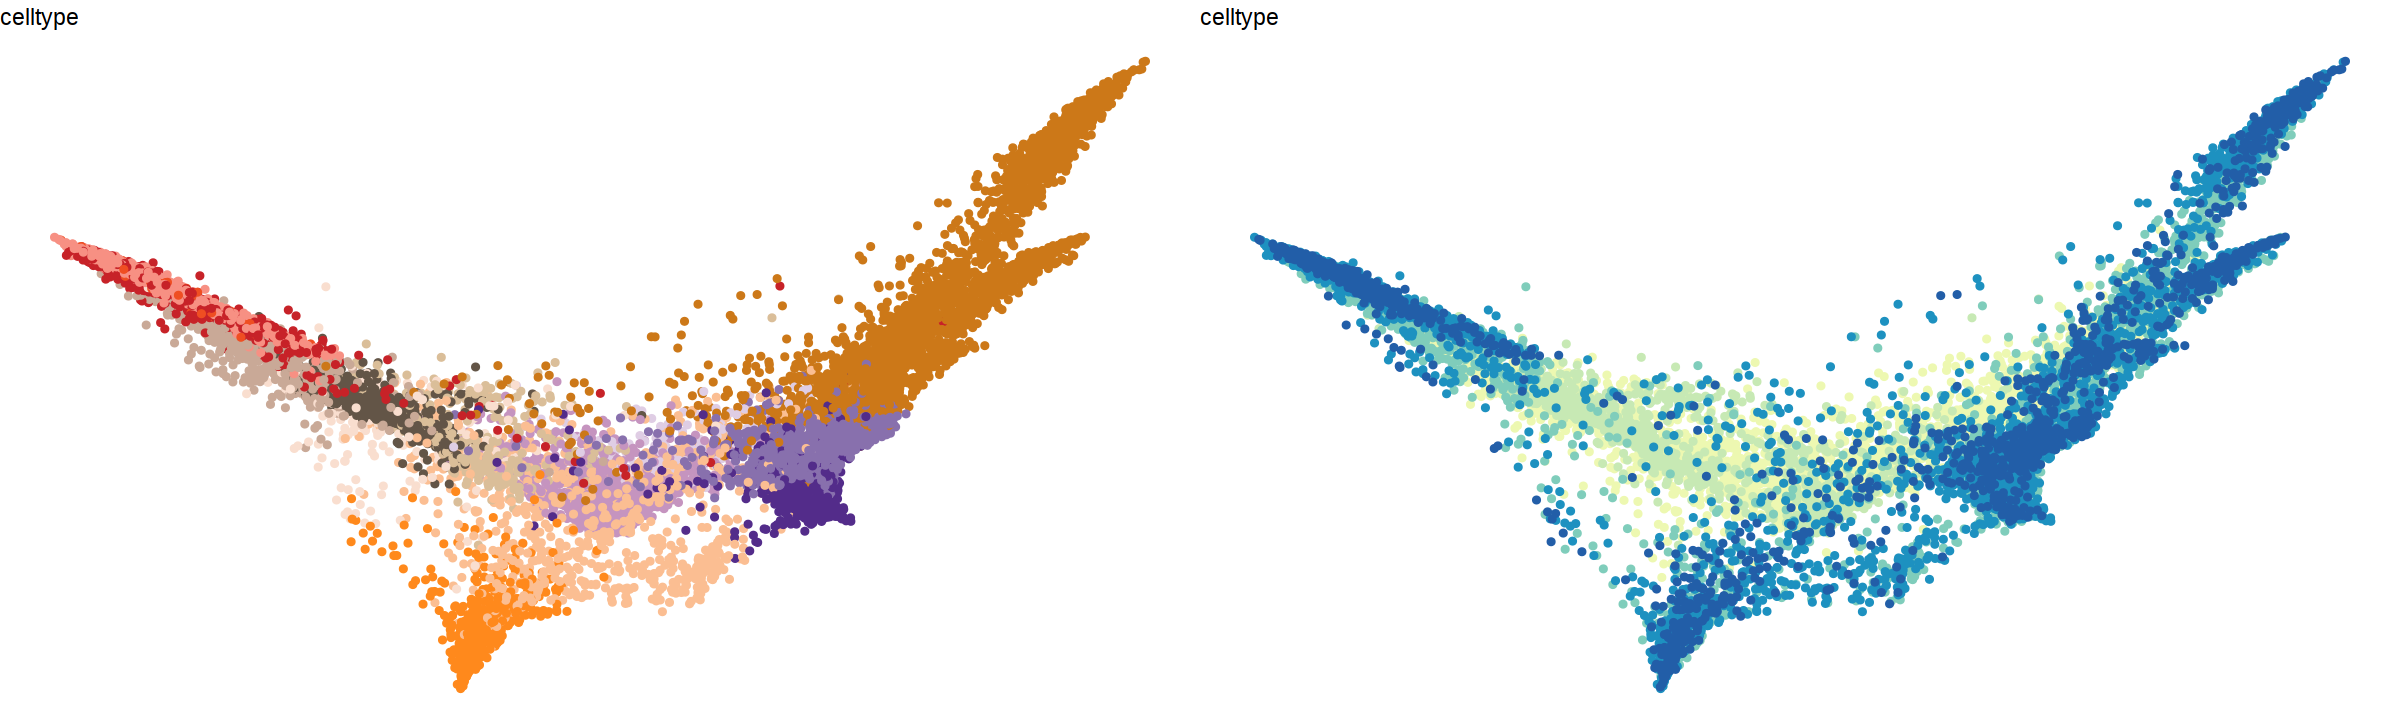

In [19]:
# Fetch dm coordinates
dm.dt <- dm.mtx %>% as.data.table %>% 
  .[,cell:=sample_metadata$cell] %>%
  setnames(c("DC1","DC2","cell")) %>%
  merge(.,sample_metadata[,c('cell', 'celltype', 'stage')], by='cell')

# Plot dm
p1 = ggplot(dm.dt, aes(DC1, DC2, col=celltype)) + 
    geom_point() + 
    scale_colour_manual(values=opts$celltype.colors) + 
    ggtitle('celltype') + 
    theme_void() + 
    theme(legend.position="none")
p2 = ggplot(dm.dt, aes(DC1, DC2, col=stage)) + 
    geom_point() + 
    scale_colour_manual(values=opts$stage.colors) + 
    ggtitle('celltype') + 
    theme_void() + 
    theme(legend.position="none")
options(repr.plot.width=20, repr.plot.height=6)

ggarrange(p1, p2)

# Model 2

In [3]:
latent = fread(sprintf('%s/results/epiblast_blood/scVI_latent2.csv', io$basedir))[-1,-1] %>%
    setnames(c(paste0('VI_', 1:25)))

In [4]:
set.seed(1234)
args$min_dist = 0.3
args$n_neighbors = 35
get_umap = function(n_neighbors = 25, min_dist=0.3, plot=FALSE){
    umap.mtx = umap(latent, 
                    n_neighbors = n_neighbors,
                    min_dist = min_dist)

    # Fetch UMAP coordinates
    umap.dt <- umap.mtx %>% as.data.table %>% 
      .[,cell:=sample_metadata$cell] %>%
      setnames(c("UMAP1","UMAP2","cell")) %>%
      merge(.,sample_metadata[,c('cell', 'celltype', 'stage')], by='cell')

    # Plot umap
    p1 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=celltype)) + 
        geom_point() + 
        scale_colour_manual(values=opts$celltype.colors) + 
        ggtitle('celltype') + 
        theme_void() + 
        theme(legend.position="none")
    p2 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=stage)) + 
        geom_point() + 
        scale_colour_manual(values=opts$stage.colors) + 
        ggtitle('celltype') + 
        theme_void() + 
        theme(legend.position="none")
    options(repr.plot.width=20, repr.plot.height=6)
    
    if(plot==TRUE){ggarrange(p1, p2)}
    else{return(umap.dt)}
    
}

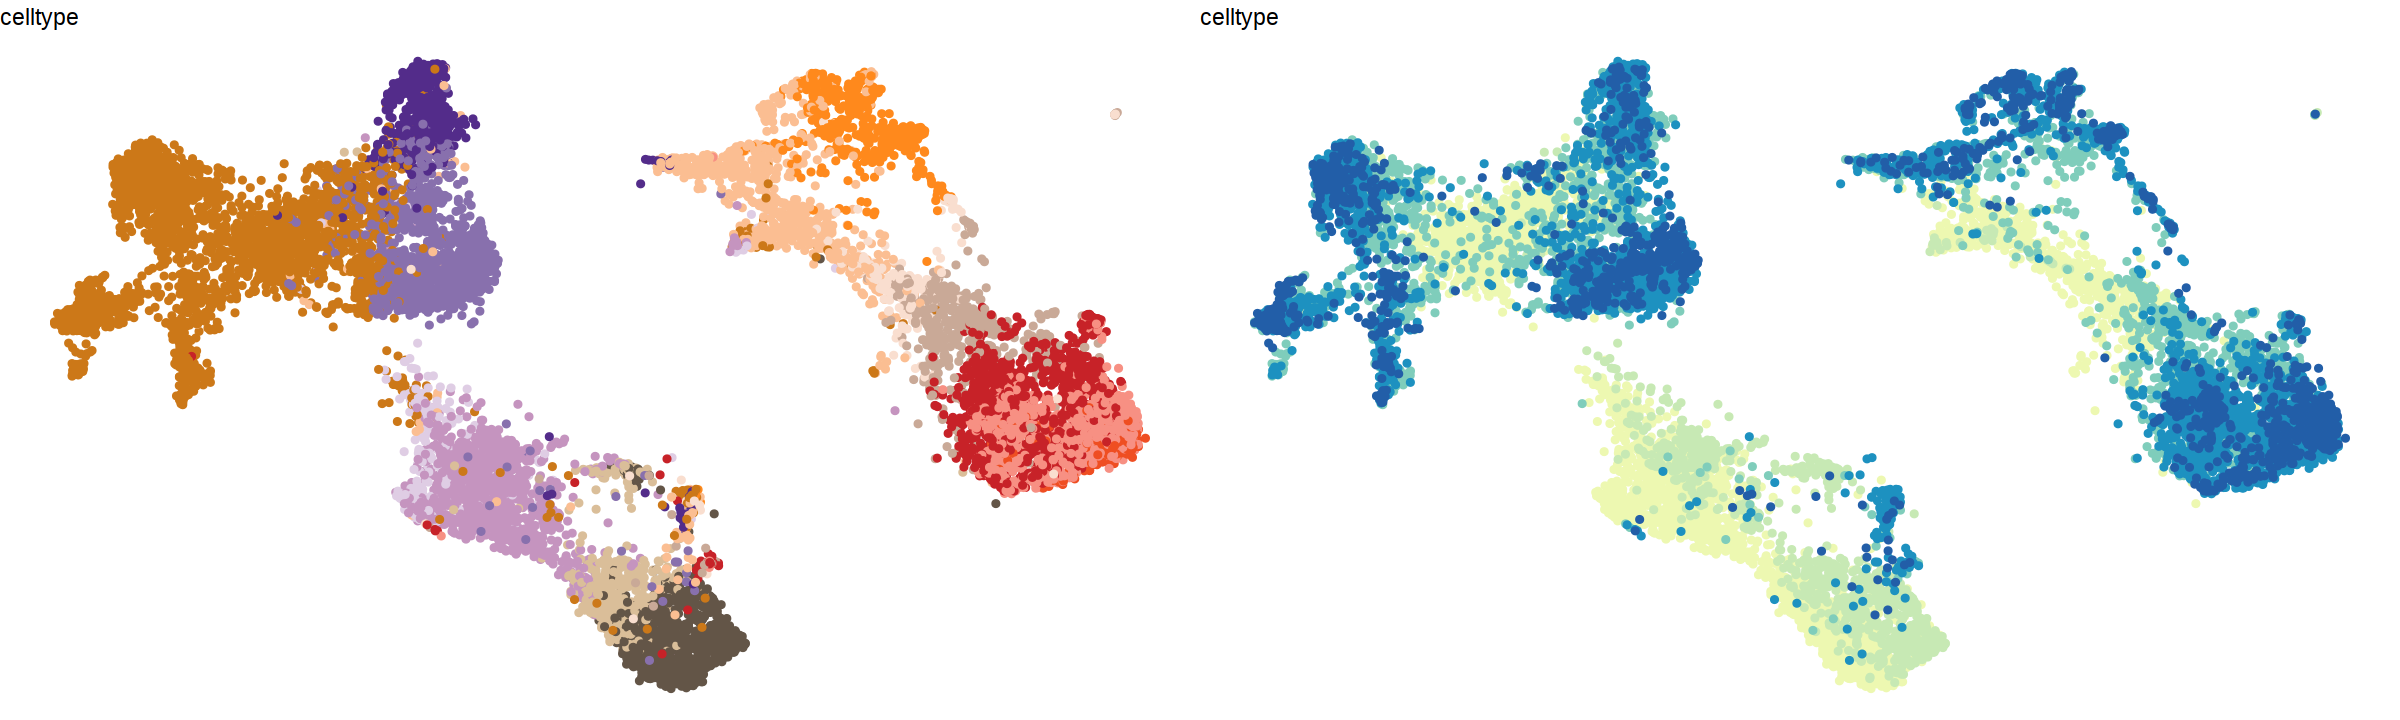

In [5]:
get_umap(20, 0.1, plot=TRUE)